# Ejercicios sugeridos – CNN aplicadas a BloodMNIST

Solución de los 5 ejercicios sugeridos usando el dataset **BloodMNIST** (8 tipos de células sanguíneas, imágenes RGB de 28×28). Debajo de cada bloque de código se incluye la interpretación de los resultados obtenidos.

In [ ]:
%pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.5 MB/s eta 0:00:00


['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
11959 1712 3421


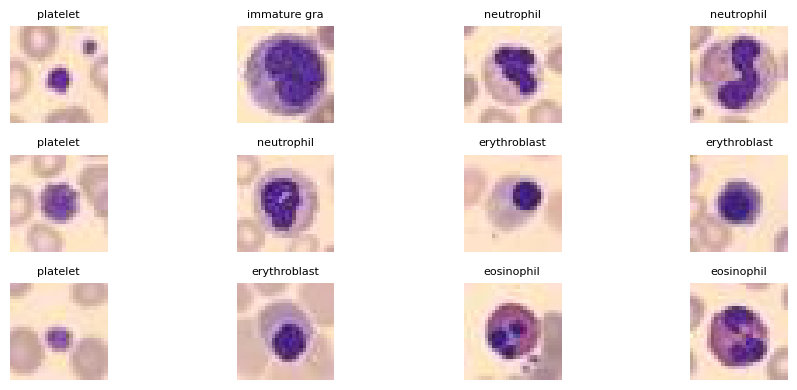

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import medmnist
from medmnist import INFO
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_flag = "bloodmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])
num_classes = len(info["label"])     # 8 clases
nombres = list(info["label"].values())
print(nombres)

# Ahora son 3 canales (RGB), por eso Normalize tiene 3 valores
transform_basic = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# root="." porque subiste bloodmnist.npz a la carpeta actual
train_dataset = DataClass(split="train", transform=transform_basic, root=".", download=False)
val_dataset   = DataClass(split="val",   transform=transform_basic, root=".", download=False)
test_dataset  = DataClass(split="test",  transform=transform_basic, root=".", download=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

# Ver ejemplos (imágenes a color)
plt.figure(figsize=(10, 4))
for i in range(12):
    x, y = train_dataset[i]
    img = x.permute(1, 2, 0) * 0.5 + 0.5   # des-normalizar para mostrar
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(nombres[int(y.item())][:12], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Interpretación – Ejercicio 4: cambio de dataset a BloodMNIST

Se reemplazó PneumoniaMNIST por **BloodMNIST**. El dataset cargó correctamente con **11,959 imágenes de entrenamiento, 1,712 de validación y 3,421 de test**, distribuidas en **8 clases** de células sanguíneas: basófilo, eosinófilo, eritroblasto, granulocito inmaduro, linfocito, monocito, neutrófilo y plaqueta.

Para adaptar el pipeline se hicieron tres cambios principales:
- **Entrada RGB (3 canales):** la normalización usa 3 valores y la primera convolución recibe 3 canales en lugar de 1.
- **Problema multiclase:** la función `evaluate` ahora usa `softmax` sobre las 8 clases y `roc_auc_score(..., multi_class="ovr")`. La versión original tomaba `probs[:, 1]`, que solo sirve para clasificación binaria.
- **Transfer learning:** ya no se necesita `x.repeat(3, 1, 1)` en ResNet, porque las imágenes ya vienen a color.

En la muestra visual se ve que las clases se distinguen por la **forma del núcleo** (el neutrófilo tiene núcleo segmentado y el eritroblasto un núcleo redondo y compacto), por el **tamaño** (la plaqueta es muy pequeña) y por el **color de los gránulos** (el eosinófilo tiene gránulos rosados/anaranjados). Por eso, en este dataset el color es información útil para clasificar.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_prob = [], []
    for x, y in loader:
        logits = model(x.to(device))
        y_prob.append(torch.softmax(logits, dim=1).cpu().numpy())   # probabilidades de las 8 clases
        y_true.append(y.squeeze(1).numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = y_prob.argmax(1)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")   # AUC multiclase
    return acc, auc, y_true, y_pred, y_prob

def entrenar(model, train_loader, epochs=10, lr=1e-3, scheduler_tipo=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = None
    if scheduler_tipo == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    elif scheduler_tipo == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    historial = {"train_loss": [], "val_acc": [], "val_auc": []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_auc, _, _, _ = evaluate(model, val_loader)
        if scheduler is not None:
            scheduler.step()
        historial["train_loss"].append(train_loss)
        historial["val_acc"].append(val_acc)
        historial["val_auc"].append(val_auc)
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")
    return historial

resultados = []   # aquí guardamos todo para comparar al final

def probar_en_test(nombre, model):
    acc, auc, _, _, _ = evaluate(model, test_loader)
    resultados.append({"modelo": nombre, "test_acc": round(acc, 4), "test_auc": round(auc, 4)})
    print(f"{nombre} | test_acc={acc:.4f} | test_auc={auc:.4f}")

Epoch 01 | train_loss=1.5711 | val_acc=0.5666 | val_auc=0.8819
Epoch 02 | train_loss=1.0165 | val_acc=0.6688 | val_auc=0.9264
Epoch 03 | train_loss=0.8654 | val_acc=0.7039 | val_auc=0.9436
Epoch 04 | train_loss=0.7956 | val_acc=0.7190 | val_auc=0.9528
Epoch 05 | train_loss=0.7172 | val_acc=0.7570 | val_auc=0.9629
Epoch 06 | train_loss=0.6535 | val_acc=0.7845 | val_auc=0.9667
Epoch 07 | train_loss=0.6094 | val_acc=0.8166 | val_auc=0.9703
Epoch 08 | train_loss=0.5671 | val_acc=0.7909 | val_auc=0.9726
Epoch 09 | train_loss=0.5477 | val_acc=0.8201 | val_auc=0.9749
Epoch 10 | train_loss=0.5327 | val_acc=0.8324 | val_auc=0.9764
SimpleCNN | test_acc=0.8144 | test_auc=0.9721
Epoch 01 | train_loss=0.9187 | val_acc=0.8125 | val_auc=0.9778
Epoch 02 | train_loss=0.4533 | val_acc=0.8791 | val_auc=0.9868
Epoch 03 | train_loss=0.3612 | val_acc=0.8621 | val_auc=0.9888
Epoch 04 | train_loss=0.3072 | val_acc=0.8803 | val_auc=0.9889
Epoch 05 | train_loss=0.2702 | val_acc=0.9001 | val_auc=0.9924
Epoch 06 

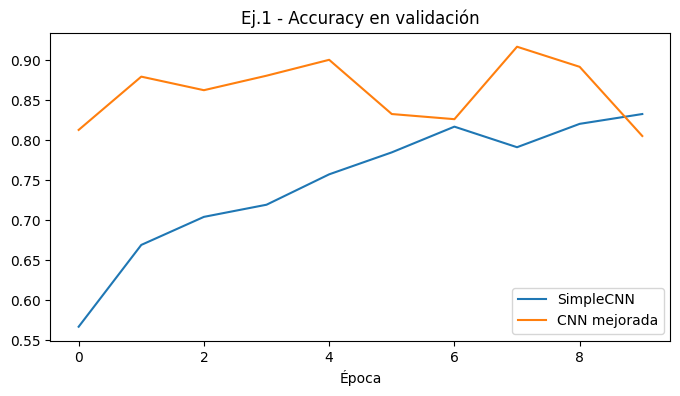

In [ ]:
# CNN original, pero con 3 canales de entrada
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

# CNN mejorada: más filtros + BatchNorm + Dropout
class CNNMejorada(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(42)
model_simple = SimpleCNN(num_classes).to(device)
hist_simple = entrenar(model_simple, train_loader, epochs=10)
probar_en_test("SimpleCNN", model_simple)

torch.manual_seed(42)
model_mejorada = CNNMejorada(num_classes).to(device)
hist_mejorada = entrenar(model_mejorada, train_loader, epochs=10)
probar_en_test("CNN mejorada (BN+Dropout+filtros)", model_mejorada)

plt.figure(figsize=(8, 4))
plt.plot(hist_simple["val_acc"], label="SimpleCNN")
plt.plot(hist_mejorada["val_acc"], label="CNN mejorada")
plt.title("Ej.1 - Accuracy en validación"); plt.xlabel("Época"); plt.legend(); plt.show()

### Interpretación – Ejercicio 1: cambio de arquitectura

| Modelo | Test accuracy | Test AUC | Train loss final |
|---|---|---|---|
| SimpleCNN | 0.8144 | 0.9721 | 0.5327 |
| CNN mejorada (BN + Dropout + más filtros) | 0.7916 | **0.9855** | **0.1860** |

- **La CNN mejorada aprende mucho más rápido.** En la primera época ya alcanza 0.8125 de accuracy en validación, casi lo mismo que la SimpleCNN logra recién en la época 10 (0.8324). BatchNorm estabiliza el entrenamiento y los filtros adicionales (32-64-128 frente a 16-32-64) le dan más capacidad para captar detalles como los gránulos y la forma del núcleo.
- **La SimpleCNN todavía no termina de aprender.** Su train loss (0.53) sigue bajando en la época 10, lo que indica *underfitting*: le faltan capacidad o épocas.
- **El AUC mejora (0.9721 → 0.9855), pero la accuracy de test baja (0.8144 → 0.7916).** La razón está en la curva de validación: la CNN mejorada oscila mucho entre épocas (0.9165 en la época 8 y 0.8049 en la época 10), y como se evalúa el modelo de la **última época**, justo se tomó un punto bajo. El AUC mide qué tan bien el modelo *ordena* las probabilidades, y en eso es claramente mejor. La accuracy depende de la clase ganadora en un momento puntual, y en ese punto el modelo estaba inestable.

**Conclusión:** la arquitectura mejorada es superior, como muestran el AUC y la velocidad de convergencia, pero con lr = 1e-3 fijo el entrenamiento es inestable. Eso motiva el Ejercicio 2.

**Observación sobre reproducibilidad:** la misma configuración (CNN mejorada, lr = 1e-3, sin aumento) se entrenó tres veces en el notebook y dio test accuracy de 0.7916, 0.8284 y 0.7892. Aunque se fija la semilla, la GPU introduce pequeñas variaciones. Por eso, diferencias de 2–4 puntos entre corridas individuales **no son concluyentes** por sí solas.


--- lr = 0.01 ---
Epoch 01 | train_loss=0.6649 | val_acc=0.8283 | val_auc=0.9782
Epoch 02 | train_loss=0.3924 | val_acc=0.7868 | val_auc=0.9820
Epoch 03 | train_loss=0.3418 | val_acc=0.8318 | val_auc=0.9857
Epoch 04 | train_loss=0.2903 | val_acc=0.8306 | val_auc=0.9916
Epoch 05 | train_loss=0.2534 | val_acc=0.9083 | val_auc=0.9924
Epoch 06 | train_loss=0.2329 | val_acc=0.9159 | val_auc=0.9955
Epoch 07 | train_loss=0.2147 | val_acc=0.8779 | val_auc=0.9930
Epoch 08 | train_loss=0.2067 | val_acc=0.8505 | val_auc=0.9892
Epoch 09 | train_loss=0.1938 | val_acc=0.9112 | val_auc=0.9945
Epoch 10 | train_loss=0.1689 | val_acc=0.8084 | val_auc=0.9868
CNN mejorada lr=0.01 | test_acc=0.7986 | test_auc=0.9859

--- lr = 0.001 ---
Epoch 01 | train_loss=0.9186 | val_acc=0.8154 | val_auc=0.9776
Epoch 02 | train_loss=0.4532 | val_acc=0.8779 | val_auc=0.9862
Epoch 03 | train_loss=0.3604 | val_acc=0.8592 | val_auc=0.9885
Epoch 04 | train_loss=0.3063 | val_acc=0.8727 | val_auc=0.9887
Epoch 05 | train_loss=

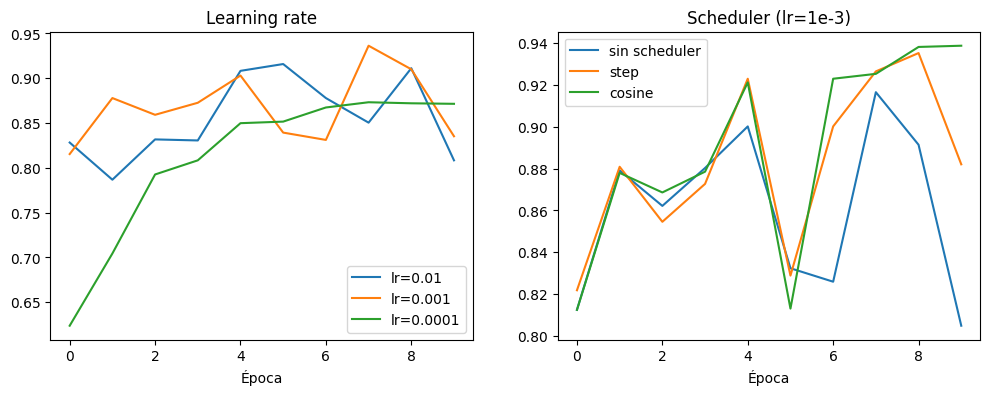

In [ ]:
historiales_lr = {}
for lr in [1e-2, 1e-3, 1e-4]:
    print(f"\n--- lr = {lr} ---")
    torch.manual_seed(42)
    m = CNNMejorada(num_classes).to(device)
    historiales_lr[f"lr={lr}"] = entrenar(m, train_loader, epochs=10, lr=lr)
    probar_en_test(f"CNN mejorada lr={lr}", m)

historiales_sched = {}
for sched in ["step", "cosine"]:
    print(f"\n--- scheduler = {sched} ---")
    torch.manual_seed(42)
    m = CNNMejorada(num_classes).to(device)
    historiales_sched[sched] = entrenar(m, train_loader, epochs=10, lr=1e-3, scheduler_tipo=sched)
    probar_en_test(f"CNN mejorada + {sched}", m)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for k, h in historiales_lr.items():
    plt.plot(h["val_acc"], label=k)
plt.title("Learning rate"); plt.xlabel("Época"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_mejorada["val_acc"], label="sin scheduler")
for k, h in historiales_sched.items():
    plt.plot(h["val_acc"], label=k)
plt.title("Scheduler (lr=1e-3)"); plt.xlabel("Época"); plt.legend()
plt.show()

### Interpretación – Ejercicio 2: learning rate y scheduler

| Configuración | Test accuracy | Test AUC | Comportamiento en validación |
|---|---|---|---|
| lr = 1e-2 | 0.7986 | 0.9859 | Aprende rápido, pero oscila mucho (0.79–0.92) |
| lr = 1e-3 | 0.8284 | 0.9892 | Mejor pico (0.9363), también inestable |
| lr = 1e-4 | 0.8690 | 0.9860 | Sube de forma suave y constante (0.62 → 0.87) |
| lr = 1e-3 + StepLR | 0.8802 | 0.9925 | Más estable al reducir el lr |
| **lr = 1e-3 + CosineAnnealing** | **0.9380** | **0.9960** | **Estable al final (0.9381, 0.9387)** |

**Learning rate:**
- **1e-2 (alto):** los pasos del optimizador son grandes y el modelo "salta" alrededor del óptimo sin asentarse, por eso la accuracy de validación sube y baja.
- **1e-3 (intermedio):** alcanza los mejores picos, pero termina en una época mala.
- **1e-4 (bajo):** es el más estable y por eso obtiene la mejor accuracy final de los tres. Sin embargo, su train loss sigue alta (0.4459) y creciendo en accuracy, lo que indica que le faltaban épocas para aprovechar todo su potencial.

**Scheduler:** los schedulers resuelven el dilema, porque empiezan con un lr alto para aprender rápido y lo reducen después para estabilizar.
- **StepLR** (divide el lr a la mitad cada 4 épocas) mejora a 0.8802.
- **CosineAnnealing** es el mejor: el lr baja suavemente hasta casi cero en la última época, así que el modelo se "asienta" y las dos últimas épocas quedan estables (0.9381 y 0.9387). Su test accuracy de **0.9380** es la mejor de todas las CNN desde cero y queda casi al nivel de ResNet18 (0.9410), con un modelo mucho más pequeño.

**Conclusión:** en este problema, **el control del learning rate importa más que la arquitectura**. La misma CNN pasó de 0.79 a 0.94 de accuracy solo por agregar un scheduler coseno.


--- Sin aumento ---
Epoch 01 | train_loss=0.9187 | val_acc=0.8248 | val_auc=0.9783
Epoch 02 | train_loss=0.4534 | val_acc=0.8785 | val_auc=0.9866
Epoch 03 | train_loss=0.3615 | val_acc=0.8586 | val_auc=0.9887
Epoch 04 | train_loss=0.3072 | val_acc=0.8756 | val_auc=0.9887
Epoch 05 | train_loss=0.2692 | val_acc=0.9019 | val_auc=0.9924
Epoch 06 | train_loss=0.2474 | val_acc=0.8370 | val_auc=0.9879
Epoch 07 | train_loss=0.2208 | val_acc=0.8259 | val_auc=0.9884
Epoch 08 | train_loss=0.2117 | val_acc=0.9340 | val_auc=0.9956
Epoch 09 | train_loss=0.1944 | val_acc=0.9036 | val_auc=0.9945
Epoch 10 | train_loss=0.1854 | val_acc=0.8061 | val_auc=0.9892
Aumento: Sin aumento | test_acc=0.7892 | test_auc=0.9873

--- Flips + rotación ---
Epoch 01 | train_loss=0.9828 | val_acc=0.8078 | val_auc=0.9755
Epoch 02 | train_loss=0.5059 | val_acc=0.8598 | val_auc=0.9836
Epoch 03 | train_loss=0.4099 | val_acc=0.8762 | val_auc=0.9890
Epoch 04 | train_loss=0.3617 | val_acc=0.8686 | val_auc=0.9871
Epoch 05 | tra

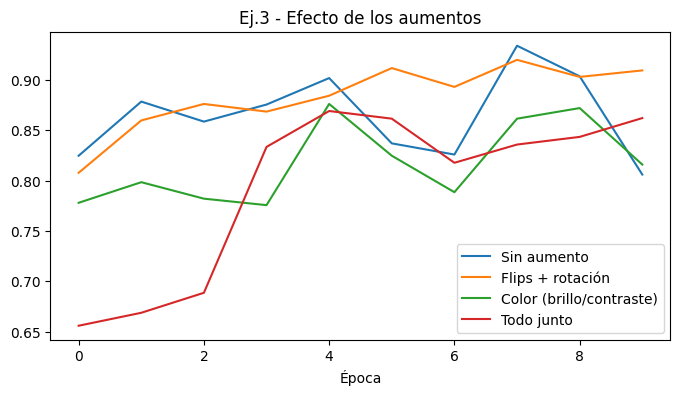

In [ ]:
normalizar = [T.ToTensor(), T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]

aumentos = {
    "Sin aumento":      [],
    "Flips + rotación": [T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(15)],
    "Color (brillo/contraste)": [T.ColorJitter(brightness=0.2, contrast=0.2)],
    "Todo junto":       [T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(15),
                         T.ColorJitter(brightness=0.2, contrast=0.2)],
}

historiales_aug = {}
for nombre, aug in aumentos.items():
    print(f"\n--- {nombre} ---")
    transform_aug = T.Compose(aug + normalizar)
    ds_aug = DataClass(split="train", transform=transform_aug, root=".", download=False)
    loader_aug = DataLoader(ds_aug, batch_size=128, shuffle=True)
    torch.manual_seed(42)
    m = CNNMejorada(num_classes).to(device)
    historiales_aug[nombre] = entrenar(m, loader_aug, epochs=10)
    probar_en_test(f"Aumento: {nombre}", m)

plt.figure(figsize=(8, 4))
for k, h in historiales_aug.items():
    plt.plot(h["val_acc"], label=k)
plt.title("Ej.3 - Efecto de los aumentos"); plt.xlabel("Época"); plt.legend(); plt.show()

### Interpretación – Ejercicio 3: impacto de los aumentos de datos

| Aumento | Test accuracy | Test AUC | Train loss final |
|---|---|---|---|
| Sin aumento | 0.7892 | 0.9873 | 0.1854 |
| **Flips + rotación** | **0.9000** | **0.9929** | 0.2533 |
| Color (brillo/contraste) | 0.8094 | 0.9849 | 0.2809 |
| Todo junto | 0.8462 | 0.9865 | 0.3519 |

- **Flips + rotación es el mejor aumento (+11 puntos de accuracy).** Tiene sentido biológico: en un frotis de sangre las células **no tienen orientación** (no existe "arriba" ni "abajo"), así que una célula rotada o volteada sigue siendo la misma célula. El modelo aprende a reconocerla sin depender de la posición. Además, su curva de validación es la más estable (0.9095 en la última época). Su train loss es más alta que sin aumento (0.25 frente a 0.19), lo que muestra que el aumento actúa como **regularización**: el modelo memoriza menos y generaliza mejor.
- **El aumento de color casi no ayuda (+2 puntos).** En este dataset el **color es una característica diagnóstica**: los gránulos anaranjados del eosinófilo o los azul-violeta del basófilo son claves para distinguirlos. Alterar brillo y contraste distorsiona parte de esa información útil.
- **Todo junto queda en un punto intermedio (0.8462).** Combinar todas las transformaciones hace la tarea más difícil: empieza muy lento (0.656 en la época 1) y su train loss (0.35) sigue alta al final. Con solo 10 épocas le falta entrenamiento; probablemente necesite más épocas para superar a flips + rotación.

**Conclusión:** los aumentos deben elegirse según el dominio. Los geométricos (flips, rotación) son válidos y muy efectivos en microscopía. Los de color deben usarse con cuidado cuando el color distingue las clases. Todos estos experimentos usaron lr = 1e-3 sin scheduler, por lo que combinar **flips + rotación con CosineAnnealing** debería dar un resultado aún mejor.

In [ ]:
import torchvision.models as models

# Ya no hace falta x.repeat(3,1,1) porque las imágenes ya son RGB
transform_tl_train = T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(), T.RandomVerticalFlip()] + normalizar)
transform_tl_eval  = T.Compose([T.Resize((224, 224))] + normalizar)

train_loader_tl = DataLoader(DataClass(split="train", transform=transform_tl_train, root=".", download=False), batch_size=64, shuffle=True)
val_loader_tl   = DataLoader(DataClass(split="val",   transform=transform_tl_eval,  root=".", download=False), batch_size=64)
test_loader_tl  = DataLoader(DataClass(split="test",  transform=transform_tl_eval,  root=".", download=False), batch_size=64)

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)   # 8 salidas
resnet = resnet.to(device)

# Descongelar solo layer4 y fc (fine-tuning parcial)
for name, param in resnet.named_parameters():
    param.requires_grad = name.startswith("layer4") or name.startswith("fc")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-4)
for epoch in range(1, 4):
    loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)
    print(f"Epoch {epoch} | loss={loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

acc, auc, y_true_tl, y_pred_tl, _ = evaluate(resnet, test_loader_tl)
resultados.append({"modelo": "ResNet18 transfer", "test_acc": round(acc, 4), "test_auc": round(auc, 4)})
print(f"ResNet18 | test_acc={acc:.4f} | test_auc={auc:.4f}")
print(classification_report(y_true_tl, y_pred_tl, target_names=[n[:15] for n in nombres], digits=4))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 56.7MB/s]


Epoch 1 | loss=0.4044 | val_acc=0.9322 | val_auc=0.9954
Epoch 2 | loss=0.1751 | val_acc=0.9480 | val_auc=0.9964
Epoch 3 | loss=0.1287 | val_acc=0.9369 | val_auc=0.9958
ResNet18 | test_acc=0.9410 | test_auc=0.9962
                 precision    recall  f1-score   support

       basophil     0.8169    0.9508    0.8788       244
     eosinophil     0.9968    0.9888    0.9928       624
   erythroblast     0.9932    0.9357    0.9636       311
immature granul     0.8253    0.9136    0.8672       579
     lymphocyte     0.9643    0.8889    0.9251       243
       monocyte     0.9693    0.7782    0.8633       284
     neutrophil     0.9758    0.9685    0.9721       666
       platelet     0.9936    0.9957    0.9947       470

       accuracy                         0.9410      3421
      macro avg     0.9419    0.9275    0.9322      3421
   weighted avg     0.9455    0.9410    0.9414      3421



### Interpretación – Ejercicio 4 (continuación): transfer learning con ResNet18

ResNet18 preentrenada en ImageNet obtuvo el **mejor resultado de todo el notebook: test accuracy = 0.9410 y AUC = 0.9962**, con solo **3 épocas** de fine-tuning (layer4 + capa final). Desde la primera época ya tenía 0.9322 en validación.

Esto confirma la ventaja del transfer learning: aunque ImageNet contiene fotos naturales y no células, los filtros preentrenados (bordes, texturas, formas) se transfieren bien a imágenes de microscopía.

**Desempeño por clase (F1-score):**
- **Muy fáciles:** plaqueta (0.9947), eosinófilo (0.9928) y neutrófilo (0.9721). Son clases con rasgos muy característicos: la plaqueta por su tamaño pequeño, el eosinófilo por sus gránulos anaranjados y el neutrófilo por su núcleo segmentado.
- **Más difíciles:**
  - **Monocito:** tiene recall de solo 0.7782, es decir, el modelo no detecta el 22% de los monocitos reales.
  - **Granulocito inmaduro:** tiene F1 de 0.8672 y precisión de 0.8253, así que recibe muchas predicciones incorrectas de otras clases.
  - **Basófilo:** tiene precisión de 0.8169.

  Morfológicamente, el monocito y los granulocitos inmaduros son células grandes con núcleos de forma parecida. A 28×28 píxeles (reescalado a 224) se pierden los detalles finos que los diferencian, así que es probable que buena parte de los monocitos no detectados se estén clasificando como granulocitos inmaduros.

**Costo-beneficio:** ResNet18 supera a la mejor CNN desde cero (CNN mejorada + coseno, 0.9380) por apenas **0.3 puntos**. A cambio, tiene alrededor de 11 millones de parámetros, trabaja con imágenes de 224×224 y es mucho más lenta. Para este dataset, una CNN pequeña bien entrenada es una alternativa casi igual de buena y mucho más eficiente.

Mejor temperatura: T = 1.70
ECE antes:   0.1021
ECE después: 0.0275
Accuracy antes/después: 0.7916 / 0.7916


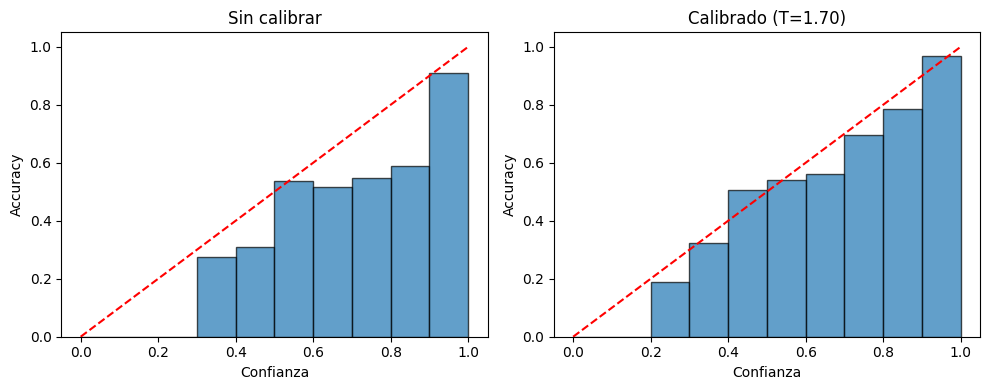

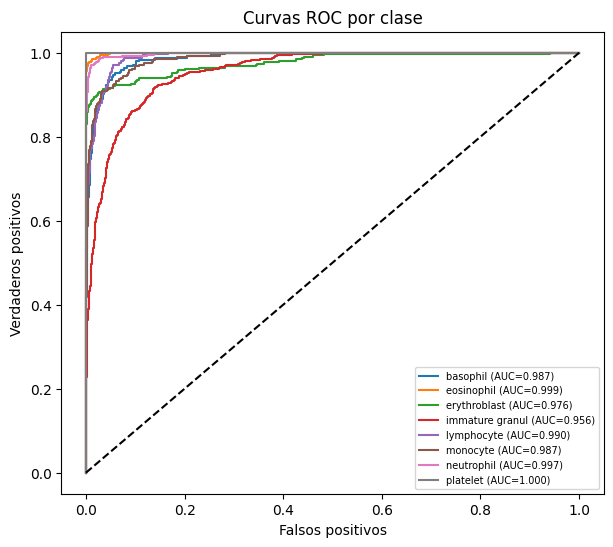

,modelo,test_acc,test_auc
0,SimpleCNN,0.8144,0.9721
1,CNN mejorada (BN+Dropout+filtros),0.7916,0.9855
2,CNN mejorada lr=0.01,0.7986,0.9859
3,CNN mejorada lr=0.001,0.8284,0.9892
4,CNN mejorada lr=0.0001,0.8690,0.9860
5,CNN mejorada + step,0.8802,0.9925
6,CNN mejorada + cosine,0.9380,0.9960
7,Aumento: Sin aumento,0.7892,0.9873
8,Aumento: Flips + rotación,0.9000,0.9929
9,Aumento: Color (brillo/contraste),0.8094,0.9849


In [ ]:
from sklearn.metrics import roc_curve, auc as calc_auc
from sklearn.preprocessing import label_binarize

@torch.no_grad()
def obtener_logits(model, loader):
    model.eval()
    L, Y = [], []
    for x, y in loader:
        L.append(model(x.to(device)).cpu())
        Y.append(y.squeeze(1).long())
    return torch.cat(L), torch.cat(Y)

def calcular_ece(probs, y, n_bins=10):
    conf = probs.max(1)
    correcto = (probs.argmax(1) == y)
    bordes = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (conf > bordes[i]) & (conf <= bordes[i + 1])
        if mask.sum() > 0:
            ece += mask.mean() * abs(correcto[mask].mean() - conf[mask].mean())
    return ece

modelo = model_mejorada   # puedes cambiarlo por otro modelo entrenado arriba

logits_val, y_val = obtener_logits(modelo, val_loader)
logits_test, y_test = obtener_logits(modelo, test_loader)

# Temperature scaling: probar varias T y quedarse con la que da menor pérdida en VALIDACIÓN
temps = np.linspace(0.5, 3.0, 26)
perdidas = [F.cross_entropy(logits_val / t, y_val).item() for t in temps]
T_opt = temps[np.argmin(perdidas)]
print(f"Mejor temperatura: T = {T_opt:.2f}")

probs_antes = torch.softmax(logits_test, 1).numpy()
probs_desp  = torch.softmax(logits_test / T_opt, 1).numpy()
y_np = y_test.numpy()

print(f"ECE antes:   {calcular_ece(probs_antes, y_np):.4f}")
print(f"ECE después: {calcular_ece(probs_desp, y_np):.4f}")
print(f"Accuracy antes/después: {accuracy_score(y_np, probs_antes.argmax(1)):.4f} / {accuracy_score(y_np, probs_desp.argmax(1)):.4f}")

# Diagrama de confiabilidad (confianza vs accuracy)
def diagrama(probs, y, titulo):
    conf = probs.max(1); correcto = (probs.argmax(1) == y)
    bordes = np.linspace(0, 1, 11); centros = (bordes[:-1] + bordes[1:]) / 2
    accs = [correcto[(conf > bordes[i]) & (conf <= bordes[i+1])].mean()
            if ((conf > bordes[i]) & (conf <= bordes[i+1])).sum() > 0 else 0 for i in range(10)]
    plt.bar(centros, accs, width=0.1, edgecolor="k", alpha=0.7)
    plt.plot([0, 1], [0, 1], "r--")
    plt.title(titulo); plt.xlabel("Confianza"); plt.ylabel("Accuracy")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); diagrama(probs_antes, y_np, "Sin calibrar")
plt.subplot(1, 2, 2); diagrama(probs_desp, y_np, f"Calibrado (T={T_opt:.2f})")
plt.tight_layout(); plt.show()

# Curvas ROC: una por clase (one-vs-rest)
Y_bin = label_binarize(y_np, classes=range(num_classes))
plt.figure(figsize=(7, 6))
for c in range(num_classes):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], probs_desp[:, c])
    plt.plot(fpr, tpr, label=f"{nombres[c][:15]} (AUC={calc_auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Curvas ROC por clase"); plt.xlabel("Falsos positivos"); plt.ylabel("Verdaderos positivos")
plt.legend(fontsize=7); plt.show()

# Resumen de todos los experimentos
pd.DataFrame(resultados)

### Interpretación – Ejercicio 5: calibración de probabilidades y curvas ROC

**Calibración (modelo: CNN mejorada del Ejercicio 1):**

| Métrica | Antes | Después (T = 1.70) |
|---|---|---|
| ECE | 0.1021 | **0.0275** |
| Accuracy | 0.7916 | 0.7916 |

- **La temperatura óptima T = 1.70 es mayor que 1**, lo que indica que el modelo original era **sobreconfiado**: daba probabilidades más altas de lo que justificaba su tasa de acierto real.
- **El diagrama de confiabilidad sin calibrar lo confirma.** En los rangos de confianza de 0.6 a 0.9, el modelo solo acertaba entre el 52% y el 59% de las veces. Es decir, cuando decía "estoy 80% seguro", en realidad acertaba poco más de la mitad de las veces. Las barras quedan claramente por debajo de la diagonal.
- **Después del temperature scaling, el ECE bajó un 73% (0.1021 → 0.0275)** y las barras quedaron mucho más cerca de la diagonal, aunque persiste una leve sobreconfianza en los rangos de 0.6 a 0.9.
- **La accuracy no cambió (0.7916).** Esto es lo esperado: dividir todos los logits por la misma T no cambia cuál clase tiene la probabilidad más alta, solo ajusta *qué tan seguras* son las probabilidades.

**¿Por qué importa en medicina?** Un modelo calibrado permite confiar en su nivel de certeza. Por ejemplo, los casos con baja confianza podrían derivarse automáticamente a revisión por un especialista.

**Curvas ROC por clase (one-vs-rest):**

| Clase | AUC |
|---|---|
| Plaqueta | 1.000 |
| Eosinófilo | 0.999 |
| Neutrófilo | 0.997 |
| Linfocito | 0.990 |
| Basófilo | 0.987 |
| Monocito | 0.987 |
| Eritroblasto | 0.976 |
| **Granulocito inmaduro** | **0.956** |

- Todas las clases tienen AUC ≥ 0.95, así que el modelo separa bien cada clase del resto.
- **El granulocito inmaduro es la clase más difícil**, con AUC de 0.956 y una curva visiblemente más alejada de la esquina superior izquierda. Esto **coincide con lo observado en ResNet18**, donde esa clase tuvo una de las precisiones más bajas. La razón probable es que agrupa varias etapas de maduración (mielocitos, metamielocitos, promielocitos) que se parecen a los neutrófilos y monocitos.
- Las clases con rasgos más distintivos (plaqueta, eosinófilo, neutrófilo) tienen AUC prácticamente perfecto.

**Observación:** este modelo tiene un AUC alto (0.9855) pero una accuracy de 0.79. Esto muestra que **AUC y accuracy miden cosas distintas**: el AUC evalúa si el modelo ordena bien las probabilidades, mientras que la accuracy solo mira la clase ganadora. Además, la calibración se aplicó al modelo del Ejercicio 1, que era inestable. Aplicarla a la CNN con scheduler coseno o a ResNet18 daría una visión más representativa del mejor modelo.

## Conclusiones generales

| Ranking | Modelo | Test accuracy | Test AUC |
|---|---|---|---|
| 1 | ResNet18 (transfer learning) | **0.9410** | **0.9962** |
| 2 | CNN mejorada + CosineAnnealing | 0.9380 | 0.9960 |
| 3 | CNN mejorada + flips/rotación | 0.9000 | 0.9929 |
| 4 | CNN mejorada + StepLR | 0.8802 | 0.9925 |
| 5 | CNN mejorada lr = 1e-4 | 0.8690 | 0.9860 |
| – | SimpleCNN (baseline) | 0.8144 | 0.9721 |

1. **El pipeline se adaptó con éxito a BloodMNIST** (RGB, 8 clases). Los cambios clave fueron los 3 canales de entrada, la evaluación multiclase con AUC one-vs-rest y quitar el `repeat` en ResNet.
2. **El learning rate y el scheduler fueron el factor más importante.** La misma CNN pasó de ~0.79 a 0.938 de accuracy solo al usar CosineAnnealing, que estabiliza el entrenamiento en las últimas épocas.
3. **La arquitectura mejorada (BatchNorm + Dropout + más filtros) converge más rápido y tiene mejor AUC**, pero sin control del learning rate es inestable.
4. **Los aumentos geométricos (flips + rotación) mejoraron 11 puntos** porque respetan la naturaleza del dominio: las células no tienen orientación. El aumento de color aportó poco porque el color es información diagnóstica.
5. **Transfer learning con ResNet18 fue el mejor modelo**, pero una CNN pequeña bien entrenada quedó a solo 0.3 puntos, con un costo computacional mucho menor.
6. **El modelo original era sobreconfiado (T = 1.70).** El temperature scaling redujo el ECE en 73% sin afectar la accuracy.
7. **La clase más difícil es el granulocito inmaduro** (AUC 0.956), seguida del monocito (recall 0.78 en ResNet), por su similitud morfológica.

**Limitaciones y trabajo futuro:** las comparaciones se basan en una sola corrida por configuración, y la variabilidad entre corridas llega a 4 puntos, así que lo ideal sería repetir cada experimento con varias semillas y promediar. También convendría guardar el modelo de la mejor época de validación (*early stopping*) en lugar de la última, combinar flips + rotación con el scheduler coseno, entrenar más épocas y aplicar la calibración al mejor modelo.

